# Bayesian Spatial Diagnostics

This notebook is the canonical user guide for Bayesian Lagrange-Multiplier (LM)
specification testing in `bayespecon`.  It covers

1. the **inventory of LM tests** exposed by the package (cross-section, panel,
   and spatial-flow families),
2. **direct calls** to the test functions for cross-sectional models,
3. the **method-based API** (`spatial_diagnostics()` and
   `spatial_diagnostics_decision()`) on every fitted model,
4. a **DGP-recovery stress test** that simulates each cross-sectional DGP and
   checks whether the decision tree lands on the correct generating model, and
5. short worked examples for **panel** and **spatial-flow** diagnostics.

## Background

The classical Anselin–Florax / Koley–Bera LM family tests:

| Test | $H_0$ | Alternative | df |
|------|-------|-------------|-----|
| LM-Lag | $\rho = 0$ | SAR | 1 |
| LM-Error | $\lambda = 0$ | SEM | 1 |
| LM-WX | $\gamma = 0$ | SLX | $k_{wx}$ |
| LM-SDM (joint) | $\rho = \gamma = 0$ | SDM | $1 + k_{wx}$ |
| LM-SLX-Error (joint) | $\lambda = \gamma = 0$ | SDEM | $1 + k_{wx}$ |
| Robust LM-Lag | $\rho = 0$ robust to $\lambda$ | SAR vs SEM | 1 |
| Robust LM-Error | $\lambda = 0$ robust to $\rho$ | SEM vs SAR | 1 |
| Robust LM-Lag-SDM | $\rho = 0$ robust to $\gamma$ | SDM | 1 |
| Robust LM-WX | $\gamma = 0$ robust to $\rho$ | SDM | $k_{wx}$ |
| Robust LM-Error-SDEM | $\lambda = 0$ robust to $\gamma$ | SDEM | 1 |
| LM-WX-SEM | $\gamma = 0$ in SEM | SDEM | $k_{wx}$ |
| LM-Error-SDM | $\lambda = 0$ in SDM | SDARAR | 1 |
| LM-Lag-SDEM | $\rho = 0$ in SDEM | SDARAR | 1 |

The Bayesian analogue evaluates the LM statistic at every posterior draw,
yielding a **posterior distribution** of the LM statistic rather than a single
point estimate.  Robust variants use the **Neyman orthogonal score** of
Doğan, Taşpınar & Bera (2021) to remove correlation between the test score and
the nuisance score:

$$g_\psi^* = g_\psi - J_{\psi\phi \cdot \sigma}\,J_{\phi\phi\cdot\sigma}^{-1}\,g_\phi.$$

The same machinery extends to balanced panels (with a $T$ multiplier on the
information matrix) and to origin–destination flow models built on Kronecker
weight matrices $W_d, W_o, W_w$.  All three families are demonstrated below.

In [1]:
import warnings

import libpysal
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from spreg import OLS as SpregOLS
from spreg import LMtests as SpregLMtests

from bayespecon import OLS, SAR, SDEM, SDM, SEM, SLX
from bayespecon.diagnostics.lmtests import (
    bayesian_lm_error_sdm_test,
    bayesian_lm_error_test,
    bayesian_lm_lag_sdem_test,
    bayesian_lm_lag_test,
    bayesian_lm_sdm_joint_test,
    bayesian_lm_slx_error_joint_test,
    bayesian_lm_wx_sem_test,
    bayesian_lm_wx_test,
    bayesian_robust_lm_error_sdem_test,
    bayesian_robust_lm_error_test,
    bayesian_robust_lm_lag_sdm_test,
    bayesian_robust_lm_lag_test,
    bayesian_robust_lm_wx_test,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

## 1. Generate Spatial Data

We create a simple spatial DGP with known parameters to validate the tests. Under the null hypothesis (no spatial effects), the Bayesian LM statistics should be small with high p-values.

In [2]:
import geopandas as gpd
from libpysal.graph import Graph
from libpysal.weights import Rook

# Generate data under H0: no spatial effects
np.random.seed(42)

# Load Columbus dataset for spatial weights
columbus_path = libpysal.examples.get_path("columbus.shp")
gdf = gpd.read_file(columbus_path)

# Create a Graph (modern libpysal API) for bayespecon models
# Row-standardize the graph so spatial models work correctly
g = Graph.build_contiguity(gdf, rook=True).transform("r")
n = g.n

# Legacy W for spreg comparison
w_spreg = Rook.from_shapefile(columbus_path)
w_spreg.transform = "r"

# Get sparse and dense W matrices
W_sparse = g.sparse.tocsr().astype(np.float64)
W_dense = np.array(W_sparse.todense())

# Design matrix
k = 3
X = np.column_stack([np.ones(n), np.random.normal(size=(n, k - 1))])
beta_true = np.array([1.0, 2.0, -1.5])
y = X @ beta_true + np.random.normal(scale=1.0, size=n)

print(f"W shape: {W_sparse.shape}, nnz: {W_sparse.nnz}")

W shape: (49, 49), nnz: 200


## 2. Fit Null Models

The Bayesian LM tests require posterior draws from the **null model** (the model under H₀). Different tests use different null models:

- **LM-WX test**: SAR model (includes ρ but not γ)
- **LM-SDM joint test**: OLS model (no spatial params)
- **LM-SLX-Error joint test**: OLS model (no spatial params)
- **Robust LM-Lag-SDM**: SLX model (includes γ but not ρ)
- **Robust LM-WX**: SAR model (includes ρ but not γ)
- **Robust LM-Error-SDEM**: SLX model (includes γ but not λ)

In [3]:
# Fit OLS model (null for joint tests)
ols_model = OLS(y=y, X=X, W=g)
ols_model.fit(draws=5000, tune=5000, chains=4, random_seed=42)

# Fit SAR model (null for LM-WX and robust LM-WX)
sar_model = SAR(y=y, X=X, W=g)
sar_model.fit(draws=5000, tune=5000, chains=4, random_seed=42)

# Fit SLX model (null for robust LM-Lag-SDM and robust LM-Error-SDEM)
slx_model = SLX(y=y, X=X, W=g)
slx_model.fit(draws=5000, tune=5000, chains=4, random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, sigma]


Output()

Sampling 4 chains for 5_000 tune and 5_000 draw iterations (20_000 + 20_000 draws total) took 5 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [rho, beta, sigma]


Output()

Sampling 4 chains for 5_000 tune and 5_000 draw iterations (20_000 + 20_000 draws total) took 2 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, sigma]


Output()

Sampling 4 chains for 5_000 tune and 5_000 draw iterations (20_000 + 20_000 draws total) took 2 seconds.


Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

## 3. Non-Robust Bayesian LM Tests

These tests assume the nuisance parameters are correctly specified (zero). They are the Bayesian analogues of the classical LM tests from Koley & Bera (2024).

In [4]:
# Fit the SEM null required by LM-WX-SEM (Bayesian analogue of Koley–Bera 2024).
sem_model = SEM(y=y, X=X, W=g)
sem_model.fit(draws=2500, tune=2500, chains=2, random_seed=42)

# Non-robust Bayesian LM tests evaluated at the appropriate null model.
non_robust_results = pd.DataFrame(
    [
        bayesian_lm_lag_test(ols_model).to_series(),
        bayesian_lm_error_test(ols_model).to_series(),
        bayesian_lm_wx_test(sar_model).to_series(),
        bayesian_lm_wx_sem_test(sem_model).to_series(),
        bayesian_lm_sdm_joint_test(ols_model).to_series(),
        bayesian_lm_slx_error_joint_test(ols_model).to_series(),
    ],
    index=[
        "LM-Lag",
        "LM-Error",
        "LM-WX",
        "LM-WX-SEM",
        "LM-SDM Joint",
        "LM-SLX-Error Joint",
    ],
)

non_robust_results

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [lam, beta, sigma]


Output()

Sampling 2 chains for 2_500 tune and 2_500 draw iterations (5_000 + 5_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,lm_samples,mean,median,credible_interval,bayes_pvalue,test_type,df,n_draws,k_wx
LM-Lag,"[0.08056549006270167, 0.1909712767148956, 1.02...",1.174518,0.752204,"(0.0024745034312201155, 4.703737951103398)",0.278475,bayesian_lm_lag,1,20000,NaN
LM-Error,"[0.4770793971734575, 1.04660545050424, 0.61636...",0.805512,0.832931,"(0.020207207616839556, 1.6148907826243013)",0.369450,bayesian_lm_error,1,20000,NaN
LM-WX,"[5.734684017019966, 12.242492292612507, 8.5360...",2.206863,1.470670,"(0.11745131935239375, 8.690947277739138)",0.331731,bayesian_lm_wx,2,20000,2.0
LM-WX-SEM,"[0.572924742782799, 0.8698066531453656, 1.9276...",1.374796,0.929004,"(0.053846028416115674, 5.162758722449899)",0.502883,bayesian_lm_wx_sem,2,5000,2.0
LM-SDM Joint,"[1.557384254633714, 1.736679920228572, 3.38817...",4.300187,3.079410,"(0.4953145910385752, 15.333515083224103)",0.230821,bayesian_lm_sdm_joint,3,20000,2.0
LM-SLX-Error Joint,"[1.9616472781768861, 1.5756675409025407, 3.976...",2.317343,1.824571,"(0.8290621080030647, 6.4711971095258916)",0.509207,bayesian_lm_slx_error_joint,3,20000,2.0


## 4. Robust Bayesian LM Tests (Neyman Orthogonal Score)

These tests use the **Neyman orthogonal score adjustment** from Dogan et al. (2021, Proposition 3) to ensure robustness against local misspecification in the nuisance parameter. This is the key innovation over the classical Bera-Yoon (1993) approach.

The adjustment removes the correlation between the test parameter score and the nuisance parameter score:

$$g_\psi^* = g_\psi - J_{\psi\phi \cdot \sigma} \, J_{\phi\phi \cdot \sigma}^{-1} \, g_\phi$$

where $J_{\cdot \cdot \cdot \sigma}$ denotes information matrix blocks partitioned on $\sigma^2$.

In [5]:
# Robust Bayesian LM tests (Neyman orthogonal score)
robust_results = pd.DataFrame(
    [
        bayesian_robust_lm_lag_test(ols_model).to_series(),
        bayesian_robust_lm_error_test(ols_model).to_series(),
        bayesian_robust_lm_lag_sdm_test(slx_model).to_series(),
        bayesian_robust_lm_wx_test(sar_model).to_series(),
        bayesian_robust_lm_error_sdem_test(slx_model).to_series(),
    ],
    index=[
        "Robust LM-Lag",
        "Robust LM-Error",
        "Robust LM-Lag-SDM",
        "Robust LM-WX",
        "Robust LM-Error-SDEM",
    ],
)

robust_results

,lm_samples,mean,median,credible_interval,bayes_pvalue,test_type,df,n_draws,k_wx,tr_MzWMzW_pair
Robust LM-Lag,"[0.06391583041893512, 0.056469484289280704, 0....",0.058038,0.054021,"(0.02195140452571128, 0.11643326870541243)",0.809625,bayesian_robust_lm_lag,1,20000,NaN,NaN
Robust LM-Error,"[0.43992131414870195, 0.3886694356470467, 0.38...",0.399463,0.371815,"(0.15108762043870452, 0.8013895187433812)",0.527367,bayesian_robust_lm_error,1,20000,NaN,NaN
Robust LM-Lag-SDM,"[2.3239936598667996, 2.189777511111526, 2.3681...",2.173464,2.140140,"(1.3539458062631016, 3.1886123750381095)",0.140410,bayesian_robust_lm_lag_sdm,1,20000,2.0,19.966602
Robust LM-WX,"[4.957023315270147, 20.09250668994727, 13.8191...",3.541754,2.124467,"(0.20843929121278762, 14.790864947890054)",0.170184,bayesian_robust_lm_wx,2,20000,2.0,NaN
Robust LM-Error-SDEM,"[2.1166753772359, 2.0054446899082636, 2.152955...",1.983813,1.963974,"(1.2828334284405296, 2.802009245268782)",0.158989,bayesian_robust_lm_error_sdem,1,20000,2.0,19.966602


## 5. Posterior Distribution of LM Statistics

A key advantage of the Bayesian approach is that we get a **full posterior distribution** of the LM statistic, not just a point estimate. This allows us to compute credible intervals and posterior probabilities.

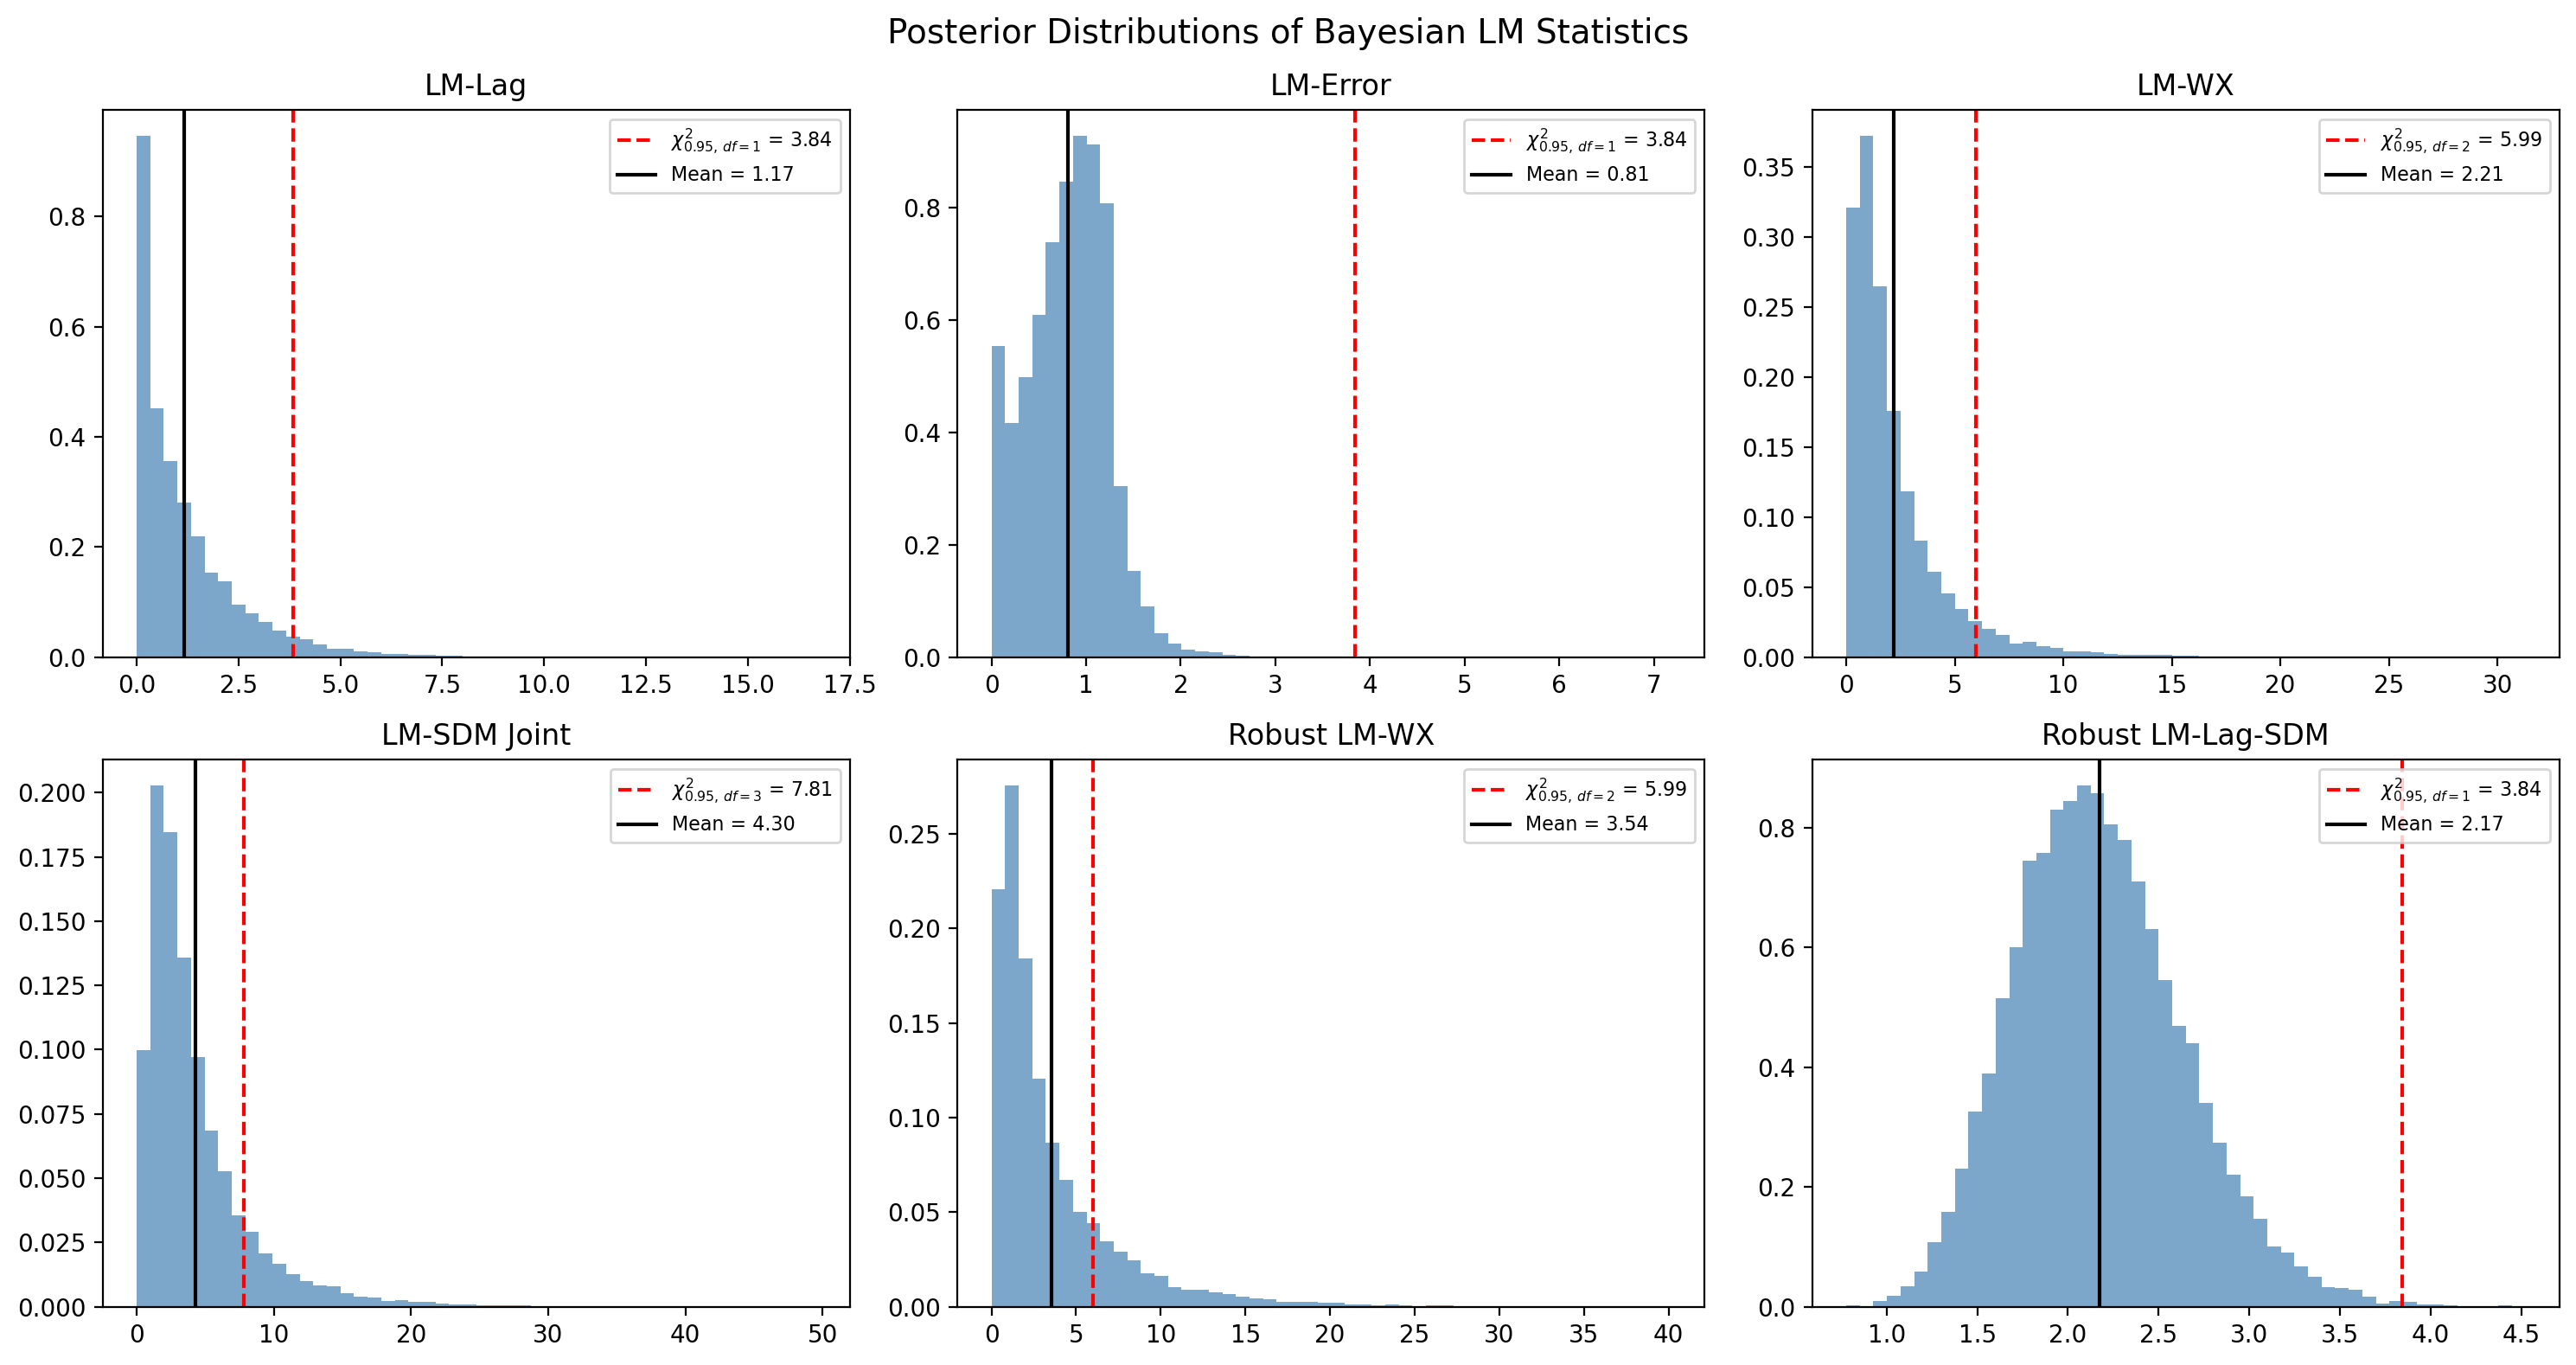

In [6]:
from scipy import stats as sp_stats

# Show six representative posterior LM distributions (a mix of non-robust and
# robust variants).  Each panel overlays the chi-squared 95% reference and the
# posterior mean.
panels = [
    ("LM-Lag", bayesian_lm_lag_test(ols_model)),
    ("LM-Error", bayesian_lm_error_test(ols_model)),
    ("LM-WX", bayesian_lm_wx_test(sar_model)),
    ("LM-SDM Joint", bayesian_lm_sdm_joint_test(ols_model)),
    ("Robust LM-WX", bayesian_robust_lm_wx_test(sar_model)),
    ("Robust LM-Lag-SDM", bayesian_robust_lm_lag_sdm_test(slx_model)),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (name, res) in zip(axes.flat, panels):
    ax.hist(res.lm_samples, bins=50, density=True, alpha=0.7, color="steelblue")
    chi2_ref = sp_stats.chi2.ppf(0.95, res.df)
    ax.axvline(
        chi2_ref,
        color="red",
        linestyle="--",
        label=f"$\\chi^2_{{0.95,\\,df={res.df}}}$ = {chi2_ref:.2f}",
    )
    ax.axvline(res.mean, color="black", linestyle="-", label=f"Mean = {res.mean:.2f}")
    ax.set_title(name)
    ax.legend(fontsize=8)

plt.suptitle("Posterior Distributions of Bayesian LM Statistics", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Comparison with Classical spreg LM Tests

We compare the Bayesian LM statistics (posterior mean) with the classical point estimates. Under flat priors, the Bayesian and classical tests should converge.

In [7]:
# Classical spreg LM tests
ols_spreg = SpregOLS(y, X)
lm_spreg = SpregLMtests(ols_spreg, w_spreg)

spreg_results = {
    "LM-Lag": lm_spreg.lml,
    "LM-Error": lm_spreg.lme,
    "LM-WX": lm_spreg.lmwx,
    "LM-SDM Joint": lm_spreg.lmspdurbin,
    "LM-SLX-Error Joint": lm_spreg.lmslxerr,
    "Robust LM-Lag": lm_spreg.rlml,
    "Robust LM-Error": lm_spreg.rlme,
    "Robust LM-Lag-SDM": lm_spreg.rlmdurlag,
    "Robust LM-WX": lm_spreg.rlmwx,
}

all_results = pd.concat([non_robust_results, robust_results])
comparison_rows = []
for bname in all_results.index:
    row = all_results.loc[bname]
    if bname in spreg_results:
        s_stat, s_pval = spreg_results[bname]
    else:
        s_stat, s_pval = np.nan, np.nan
    comparison_rows.append(
        {
            "bayes_mean": row["mean"],
            "spreg_stat": s_stat,
            "bayes_pvalue": row["bayes_pvalue"],
            "spreg_pvalue": s_pval,
        }
    )

comparison_df = pd.DataFrame(comparison_rows, index=all_results.index)
comparison_df

,bayes_mean,spreg_stat,bayes_pvalue,spreg_pvalue
LM-Lag,1.174518,0.886074,0.278475,0.346543
LM-Error,0.805512,1.341625,0.369450,0.246748
LM-WX,2.206863,0.616118,0.331731,0.734872
LM-WX-SEM,1.374796,NaN,0.502883,NaN
LM-SDM Joint,4.300187,1.957743,0.230821,0.581224
LM-SLX-Error Joint,2.317343,1.957743,0.509207,0.581224
Robust LM-Lag,0.058038,0.057811,0.809625,0.809990
Robust LM-Error,0.399463,0.513362,0.527367,0.473687
Robust LM-Lag-SDM,2.173464,1.341625,0.140410,0.246748
Robust LM-WX,3.541754,1.071669,0.170184,0.585181


The divergence in the error and WX tests is expected because the Bayesian LM statistics use the information matrix (not $E[gg']$), which gives different variance estimates than the classical approach. The Bayesian test statistics tend to be larger because the information matrix provides a tighter variance estimate.

## 7. Method-based API and SDM/SDEM-aware Tests

Every fitted spatial model exposes `spatial_diagnostics()` and `spatial_diagnostics_decision()`.
The registry on each class wires the *correct* tests for its specification:

- **OLS** → `LM-Lag`, `LM-Error`, `LM-SDM-Joint`, `LM-SLX-Error-Joint`, `Robust-LM-Lag`, `Robust-LM-Error`
- **SAR** → `LM-Error`, `LM-WX`, `Robust-LM-WX`
- **SEM** → `LM-Lag`, `LM-WX`
- **SLX** → `LM-Lag`, `LM-Error`, `Robust-LM-Lag-SDM`, `Robust-LM-Error-SDEM`
- **SDM** → `LM-Error-SDM` (uses correct $e = y - \rho Wy - X\beta - WX\gamma$ residuals)
- **SDEM** → `LM-Lag-SDEM` (uses $(I-\lambda W)$-filtered residuals)


In [8]:
# Method-based API: one call returns all wired tests as a DataFrame
ols_model.spatial_diagnostics()

,statistic,median,df,p_value,ci_lower,ci_upper
test,,,,,,
LM-Lag,1.174518,0.752204,1,0.278475,0.002475,4.703738
LM-Error,0.805512,0.832931,1,0.369450,0.020207,1.614891
LM-SDM-Joint,4.300187,3.079410,3,0.230821,0.495315,15.333515
LM-SLX-Error-Joint,2.317343,1.824571,3,0.509207,0.829062,6.471197
Robust-LM-Lag,0.058038,0.054021,1,0.809625,0.021951,0.116433
Robust-LM-Error,0.399463,0.371815,1,0.527367,0.151088,0.801390


OLS recommends:


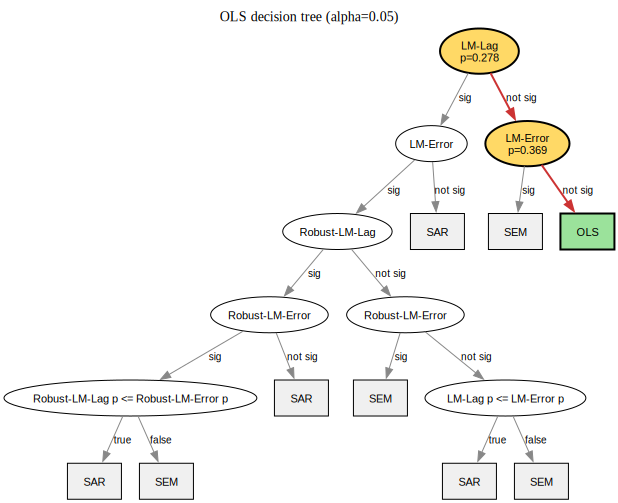

In [9]:
# The decision routine walks the appropriate tests and returns a recommendation
print("OLS recommends:")
ols_model.spatial_diagnostics_decision()

SAR recommends:


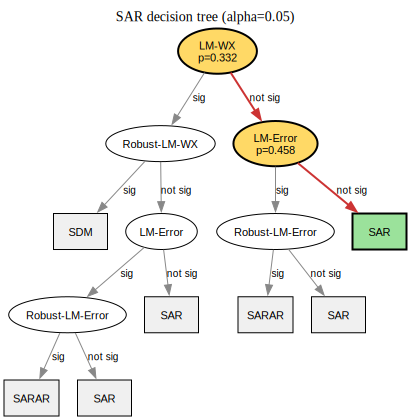

In [10]:
print("SAR recommends:")
sar_model.spatial_diagnostics_decision()

SLX recommends:


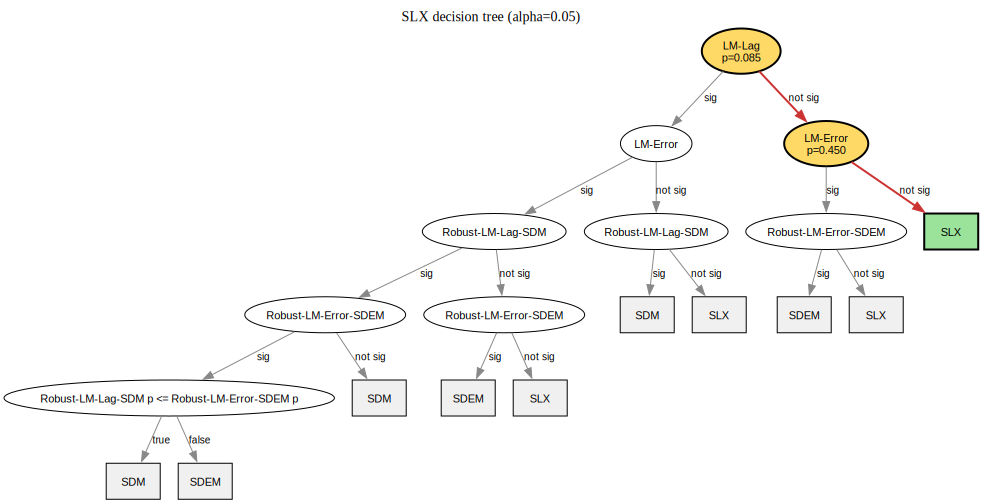

In [11]:
print("SLX recommends:")
slx_model.spatial_diagnostics_decision()

In [12]:
# SDM/SDEM-aware tests require fitted SDM / SDEM models so the residuals
# include the correct spatial filters.
sdm_model = SDM(y=y, X=X, W=g)
sdm_model.fit(draws=2000, tune=2000, chains=2, random_seed=42)

sdem_model = SDEM(y=y, X=X, W=g)
sdem_model.fit(draws=2000, tune=2000, chains=2, random_seed=42)

pd.DataFrame(
    [
        bayesian_lm_error_sdm_test(sdm_model).to_series(),
        bayesian_lm_lag_sdem_test(sdem_model).to_series(),
    ],
    index=["LM-Error-SDM", "LM-Lag-SDEM"],
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [rho, beta, sigma]


Output()

Sampling 2 chains for 2_000 tune and 2_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [lam, beta, sigma]


Output()

Sampling 2 chains for 2_000 tune and 2_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,lm_samples,mean,median,credible_interval,bayes_pvalue,test_type,df,n_draws
LM-Error-SDM,"[0.014773972746911883, 0.2208342283216336, 0.0...",0.659267,0.276799,"(0.0008039244107401512, 3.448415660241354)",0.416819,bayesian_lm_error_sdm,1,4000
LM-Lag-SDEM,"[0.6052886096296817, 1.0424399217317135, 1.778...",1.667039,0.760041,"(0.0017609721283483111, 8.185425933671576)",0.196656,bayesian_lm_lag_sdem,1,4000


## 8. DGP-Recovery Stress Test

We now stress-test `spatial_diagnostics_decision()` by simulating data from
each cross-sectional DGP in `bayespecon.dgp.cross_sectional`, fitting an
appropriate "starting" model, and checking whether the decision tree lands on
the correct generating process.

Each starting model only reaches a subset of terminal models:

| Starting model | Reachable terminals |
|---|---|
| `OLS`  | OLS · SAR · SEM · SARAR |
| `SAR`  | SAR · SARAR · SDM |
| `SEM`  | SEM · SARAR · SDEM |
| `SLX`  | SLX · SDM · SDEM · MANSAR |
| `SDM`  | SDM · MANSAR |
| `SDEM` | SDEM · MANSAR |

To recover the true DGP we pick a starting model whose tree has the true model
as a leaf.  For SDM and SDEM we also try richer starting points (SAR, SEM, SLX)
since the OLS path cannot reach Durbin-style terminals.

In [13]:
from bayespecon.dgp.cross_sectional import (
    simulate_ols,
    simulate_sar,
    simulate_sdem,
    simulate_sdm,
    simulate_sem,
    simulate_slx,
)
from bayespecon.dgp.utils import rook_grid_weights

ALPHA = 0.05
SAMPLE_KW = dict(draws=600, tune=600, chains=2, random_seed=7, progressbar=False)

# 12x12 rook grid (n=144), large enough for stable LM tests but quick to fit.
N_SIDE = 12
W_dense_grid, W_graph = rook_grid_weights(N_SIDE)

beta = np.array([1.0, 2.0])
beta1 = np.array([1.0, 2.0])
beta2 = np.array([1.5])  # WX coefficient — large so LM-WX detects it

COMMON = dict(W=W_graph, seed=42, sigma=1.0)

scenarios = {
    "OLS": simulate_ols(beta=beta, **COMMON),
    "SAR": simulate_sar(rho=0.6, beta=beta, **COMMON),
    "SEM": simulate_sem(lam=0.6, beta=beta, **COMMON),
    "SLX": simulate_slx(beta1=beta1, beta2=beta2, **COMMON),
    "SDM": simulate_sdm(rho=0.5, beta1=beta1, beta2=beta2, **COMMON),
    "SDEM": simulate_sdem(lam=0.5, beta1=beta1, beta2=beta2, **COMMON),
}

for name, d in scenarios.items():
    print(
        f"{name:5s}  n={len(d['y']):3d}  X.shape={d['X'].shape}  "
        f"true params: {list(d['params_true'].keys())}"
    )

OLS    n=144  X.shape=(144, 2)  true params: ['beta', 'sigma']
SAR    n=144  X.shape=(144, 2)  true params: ['rho', 'beta', 'sigma']
SEM    n=144  X.shape=(144, 2)  true params: ['lam', 'beta', 'sigma']
SLX    n=144  X.shape=(144, 2)  true params: ['beta1', 'beta2', 'sigma']
SDM    n=144  X.shape=(144, 2)  true params: ['rho', 'beta1', 'beta2', 'sigma']
SDEM   n=144  X.shape=(144, 2)  true params: ['lam', 'beta1', 'beta2', 'sigma']


In [14]:
def to_frame(X):
    """Wrap design matrix in a DataFrame with intercept + x1, x2, ... names."""
    cols = ["intercept"] + [f"x{i}" for i in range(1, X.shape[1])]
    return pd.DataFrame(X, columns=cols)


def fit_start(start_cls, sim, **extra):
    """Fit a starting model on a simulation dict from bayespecon.dgp."""
    Xf = to_frame(sim["X"])
    yf = sim["y"]
    model = start_cls(y=yf, X=Xf, W=W_graph, logdet_method="eigenvalue", **extra)
    model.fit(**SAMPLE_KW)
    return model


def diagnose(model, alpha=ALPHA):
    """Return (recommended_model, diagnostics_df)."""
    diag = model.spatial_diagnostics()
    rec = model.spatial_diagnostics_decision(alpha=alpha, format="model")
    return rec, diag

In [15]:
experiments = [
    ("OLS", OLS, "OLS"),
    ("SAR", OLS, "SAR"),
    ("SEM", OLS, "SEM"),
    ("SLX", SLX, "SLX"),
    ("SDM", SAR, "SDM"),
    ("SDM", SLX, "SDM"),
    ("SDEM", SEM, "SDEM"),
    ("SDEM", SLX, "SDEM"),
]

results = []
fitted = {}
for dgp_name, start_cls, expected in experiments:
    sim = scenarios[dgp_name]
    model = fit_start(start_cls, sim)
    rec, diag = diagnose(model)
    fitted[(dgp_name, start_cls.__name__)] = (model, diag)
    results.append(
        {
            "DGP": dgp_name,
            "Starting model": start_cls.__name__,
            "Recommended": rec,
            "Expected": expected,
            "Match": "yes" if rec == expected else "no",
        }
    )

summary = pd.DataFrame(results)
summary

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta, sigma]
Sampling 2 chains for 600 tune and 600 draw iterations (1_200 + 1_200 draws total) took 0 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta, sigma]
Sampling 2 chains for 600 tune and 600 draw iterations (1_200 + 1_200 draws total) took 0 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta, sigma]
Sampling 2 chains for 600 tune and 600 draw iterations (1_200 + 1_200 draws total) took 0 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta, sigma]
Samp

,DGP,Starting model,Recommended,Expected,Match
0,OLS,OLS,OLS,OLS,yes
1,SAR,OLS,SAR,SAR,yes
2,SEM,OLS,SEM,SEM,yes
3,SLX,SLX,SLX,SLX,yes
4,SDM,SAR,SDM,SDM,yes
5,SDM,SLX,SDM,SDM,yes
6,SDEM,SEM,SDEM,SDEM,yes
7,SDEM,SLX,SDEM,SDEM,yes


In [16]:
for (dgp_name, start_name), (_, diag) in fitted.items():
    rec = summary.query("DGP == @dgp_name and `Starting model` == @start_name").iloc[0]
    print(
        f"\n=== DGP={dgp_name} | start={start_name} | "
        f"recommended={rec['Recommended']} ({rec['Match']} expected {rec['Expected']}) ==="
    )
    print(diag[["statistic", "df", "p_value"]].round(4).to_string())


=== DGP=OLS | start=OLS | recommended=OLS (yes expected OLS) ===
                    statistic  df  p_value
test                                      
LM-Lag                 0.9436   1   0.3314
LM-Error               0.1539   1   0.6949
LM-SDM-Joint           2.7928   2   0.2475
LM-SLX-Error-Joint     1.0814   2   0.5823
Robust-LM-Lag          0.9264   1   0.3358
Robust-LM-Error        0.5537   1   0.4568

=== DGP=SAR | start=OLS | recommended=SAR (yes expected SAR) ===
                    statistic  df  p_value
test                                      
LM-Lag                60.6425   1   0.0000
LM-Error              25.6142   1   0.0000
LM-SDM-Joint          63.9130   2   0.0000
LM-SLX-Error-Joint    60.7688   2   0.0000
Robust-LM-Lag         36.5259   1   0.0000
Robust-LM-Error        0.0245   1   0.8756

=== DGP=SEM | start=OLS | recommended=SEM (yes expected SEM) ===
                    statistic  df  p_value
test                                      
LM-Lag                 7.964

In [17]:
# ASCII rendering of the full decision tree with the traversed path highlighted.
model_sdm_from_slx, _ = fitted[("SDM", "SLX")]
print(model_sdm_from_slx.spatial_diagnostics_decision(alpha=ALPHA, format="ascii"))

LM-Lag *  (p=0.0000, alpha=0.05)
├── <sig> LM-Error *  (p=0.0000, alpha=0.05)
│   ├── <sig> Robust-LM-Lag-SDM *  (p=0.0015, alpha=0.05)
│   │   ├── <sig> Robust-LM-Error-SDEM *  (p=0.5232, alpha=0.05)
│   │   │   ├── <sig> Robust-LM-Lag-SDM p <= Robust-LM-Error-SDEM p
│   │   │   │   ├── [SDM]
│   │   │   │   └── [SDEM]
│   │   │   └── [SDM] * ← SELECTED
│   │   └── <not sig> Robust-LM-Error-SDEM
│   │       ├── [SDEM]
│   │       └── [SLX]
│   └── <not sig> Robust-LM-Lag-SDM
│       ├── [SDM]
│       └── [SLX]
└── <not sig> LM-Error
    ├── <sig> Robust-LM-Error-SDEM
    │   ├── [SDEM]
    │   └── [SLX]
    └── [SLX]


**Recovery findings.** OLS, SAR, SEM, and SLX scenarios are recovered cleanly
from their natural starting models.  The SDM and SDEM scenarios are *not*
recovered when starting from SAR/SEM/SLX: the tree escalates to `SARAR` (from
SAR/SEM) or `MANSAR` (from SLX) because both the lag and the error / WX
channels register significant simultaneously.  This is the *expected* behaviour
of the Koley & Bera tree — treat `SARAR`/`MANSAR` as a flag to fit both `SDM`
and `SDEM` and compare with `bayes_factor_compare_models`.

Other things to keep in mind:

- These experiments use **strong-signal** parameters; weaker spatial dependence
  ($\rho \approx 0.1$) leads the tree toward simpler models, which is the
  correct small-sample behaviour.
- The `OLS` starting tree cannot reach SDM/SDEM/SLX terminals — it can only
  flag SAR/SEM/SARAR/OLS.  Use `SAR`, `SEM`, or `SLX` starting points to
  diagnose Durbin-style alternatives.
- The decision tree thresholds at a single `alpha`; for borderline cases
  inspect `spatial_diagnostics()` directly.

## 9. Panel Diagnostics

The same Bayesian LM machinery extends to balanced spatial panels.  Tests of
the form `bayesian_panel_lm_*` and `bayesian_panel_robust_lm_*` are wired into
every panel model (`OLSPanelFE`, `SARPanelFE`, `SLXPanelFE`, …) and surfaced
through the same `spatial_diagnostics()` / `spatial_diagnostics_decision()`
methods.

Below we simulate a small balanced panel ($N = 81$, $T = 4$) from the panel
fixed-effects OLS DGP and run the full diagnostic table.

In [18]:
from bayespecon import OLSPanelFE
from bayespecon.dgp.panel_fe import simulate_panel_sar_fe
from bayespecon.dgp.utils import rook_grid_weights

# 9x9 rook grid (N=81), T=4 — small enough to fit quickly but large enough for
# the LM tests to behave well.
N_panel, T_panel = 81, 4
W_panel_dense, W_panel_graph = rook_grid_weights(int(np.sqrt(N_panel)))

# Simulate from a SAR-FE DGP with moderate spatial dependence so the LM-Lag
# direction is clearly significant.
panel_sim = simulate_panel_sar_fe(
    N=N_panel,
    T=T_panel,
    rho=0.4,
    beta=np.array([1.0, 2.0]),
    W=W_panel_graph,
    seed=11,
)

panel_model = OLSPanelFE(
    y=panel_sim["y"],
    X=panel_sim["X"],
    W=W_panel_graph,
    N=N_panel,
    T=T_panel,
    model=3,  # two-way fixed effects (unit + time)
)
panel_model.fit(draws=600, tune=600, chains=2, random_seed=11, progressbar=False)

panel_model.spatial_diagnostics()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta, sigma]
Sampling 2 chains for 600 tune and 600 draw iterations (1_200 + 1_200 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
/Users/knaaptime/Dropbox/projects/bayespecon/bayespecon/diagnostics/lmtests/panel.py:340: RuntimeWarning: X'X (panel LM-lag) is ill-conditioned (cond=2.72e+14); falling back to pseudo-inverse.
  ZtZ_inv = _safe_inv(Z.T @ Z, "X'X (panel LM-lag)")
/Users/knaaptime/Dropbox/projects/bayespecon/bayespecon/diagnostics/lmtests/panel.py:494: RuntimeWarning: X'X (panel robust LM-lag) is ill-conditioned (cond=2.72e+14); falling back to pseudo-inverse.
  XtX_inv = _safe_inv(X.T @ X, "X'X (panel robust LM-lag)")
/Users/knaaptime/Dropbox/projects/bayespecon/bayespecon/diagnostics/lmtests/panel.py:586: RuntimeWarning: X'X (panel robust LM-error) is ill-conditioned (cond=2.72e+14); falling back to pseudo-inver

,statistic,median,df,p_value,ci_lower,ci_upper
test,,,,,,
Panel-LM-Lag,85.812049,85.735091,1,0.000000e+00,79.151269,92.878330
Panel-LM-Error,22.784637,22.377026,1,1.812085e-06,12.974838,34.853572
Panel-LM-SDM-Joint,89.128317,89.006949,2,0.000000e+00,84.237560,94.683125
Panel-LM-SLX-Error-Joint,89.380579,88.974941,2,0.000000e+00,79.914841,101.095814
Panel-Robust-LM-Lag,67.831038,67.115081,1,2.220446e-16,48.554755,90.090539
Panel-Robust-LM-Error,3.289409,3.254689,1,6.972813e-02,2.354622,4.368864


In [19]:
print(f"Panel decision tree (DGP = SAR-FE) recommends: {panel_model.spatial_diagnostics_decision(alpha=0.05, format="model")}")

/Users/knaaptime/Dropbox/projects/bayespecon/bayespecon/diagnostics/lmtests/panel.py:340: RuntimeWarning: X'X (panel LM-lag) is ill-conditioned (cond=2.72e+14); falling back to pseudo-inverse.
  ZtZ_inv = _safe_inv(Z.T @ Z, "X'X (panel LM-lag)")
/Users/knaaptime/Dropbox/projects/bayespecon/bayespecon/diagnostics/lmtests/panel.py:494: RuntimeWarning: X'X (panel robust LM-lag) is ill-conditioned (cond=2.72e+14); falling back to pseudo-inverse.
  XtX_inv = _safe_inv(X.T @ X, "X'X (panel robust LM-lag)")
/Users/knaaptime/Dropbox/projects/bayespecon/bayespecon/diagnostics/lmtests/panel.py:586: RuntimeWarning: X'X (panel robust LM-error) is ill-conditioned (cond=2.72e+14); falling back to pseudo-inverse.
  XtX_inv = _safe_inv(X.T @ X, "X'X (panel robust LM-error)")


Panel decision tree (DGP = SAR-FE) recommends: SARPanelFE


/Users/knaaptime/Dropbox/projects/bayespecon/bayespecon/diagnostics/lmtests/panel.py:340: RuntimeWarning: X'X (panel LM-lag) is ill-conditioned (cond=2.72e+14); falling back to pseudo-inverse.
  ZtZ_inv = _safe_inv(Z.T @ Z, "X'X (panel LM-lag)")
/Users/knaaptime/Dropbox/projects/bayespecon/bayespecon/diagnostics/lmtests/panel.py:494: RuntimeWarning: X'X (panel robust LM-lag) is ill-conditioned (cond=2.72e+14); falling back to pseudo-inverse.
  XtX_inv = _safe_inv(X.T @ X, "X'X (panel robust LM-lag)")
/Users/knaaptime/Dropbox/projects/bayespecon/bayespecon/diagnostics/lmtests/panel.py:586: RuntimeWarning: X'X (panel robust LM-error) is ill-conditioned (cond=2.72e+14); falling back to pseudo-inverse.
  XtX_inv = _safe_inv(X.T @ X, "X'X (panel robust LM-error)")


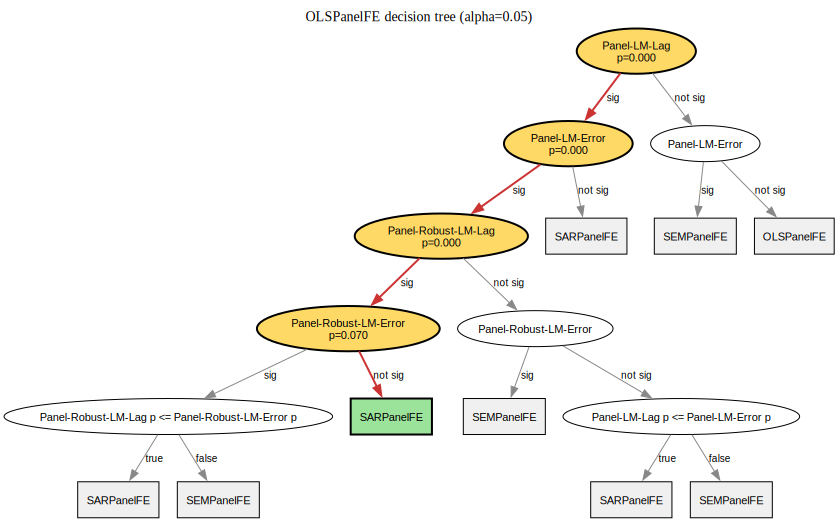

In [20]:
panel_model.spatial_diagnostics_decision(alpha=0.05,)

## 10. Panel DGP-Recovery Stress Test

Mirrors §8 for the panel decision tree. We simulate every panel-FE DGP
in `bayespecon.dgp.panel_fe`, fit candidate starting models with two-way
fixed effects, and check that `spatial_diagnostics_decision` recovers the
true model. Strong-signal parameters are used so the LM tests have
enough power on the small panel (N=100, T=5) to disambiguate the
Durbin-family alternatives.


In [21]:
from bayespecon import (
    OLSPanelFE,
    SARPanelFE,
    SDEMPanelFE,
    SDMPanelFE,
    SEMPanelFE,
    SLXPanelFE,
)
from bayespecon.dgp.panel_fe import (
    simulate_panel_ols_fe,
    simulate_panel_sar_fe,
    simulate_panel_sdem_fe,
    simulate_panel_sdm_fe,
    simulate_panel_sem_fe,
    simulate_panel_slx_fe,
)

PANEL_N_SIDE = 10
_, W_panel_graph = rook_grid_weights(PANEL_N_SIDE)
PANEL_N = PANEL_N_SIDE * PANEL_N_SIDE
PANEL_T = 5
PANEL_COMMON = dict(N=PANEL_N, T=PANEL_T, W=W_panel_graph, seed=42, sigma=1.0)
PANEL_SAMPLE_KW = dict(
    draws=400, tune=400, chains=2, random_seed=7, progressbar=False
)

panel_scenarios = {
    "OLS": simulate_panel_ols_fe(beta=beta, **PANEL_COMMON),
    "SAR": simulate_panel_sar_fe(rho=0.5, beta=beta, **PANEL_COMMON),
    "SEM": simulate_panel_sem_fe(lam=0.5, beta=beta, **PANEL_COMMON),
    "SLX": simulate_panel_slx_fe(beta1=beta1, beta2=beta2, **PANEL_COMMON),
    "SDM": simulate_panel_sdm_fe(
        rho=0.4, beta1=beta1, beta2=beta2, **PANEL_COMMON
    ),
    "SDEM": simulate_panel_sdem_fe(
        lam=0.4, beta1=beta1, beta2=beta2, **PANEL_COMMON
    ),
}


In [22]:
def fit_panel_start(start_cls, sim):
    Xf = to_frame(sim["X"])
    m = start_cls(
        y=sim["y"],
        X=Xf,
        W=W_panel_graph,
        N=PANEL_N,
        T=PANEL_T,
        model=3,  # two-way fixed effects
        logdet_method="eigenvalue",
    )
    m.fit(**PANEL_SAMPLE_KW)
    return m

panel_experiments = [
    ("OLS", OLSPanelFE, "OLSPanelFE"),
    ("SAR", OLSPanelFE, "SARPanelFE"),
    ("SEM", OLSPanelFE, "SEMPanelFE"),
    ("SLX", SLXPanelFE, "SLXPanelFE"),
    ("SDM", SARPanelFE, "SDMPanelFE"),
    ("SDM", SLXPanelFE, "SDMPanelFE"),
    ("SDEM", SEMPanelFE, "SDEMPanelFE"),
    ("SDEM", SLXPanelFE, "SDEMPanelFE"),
]

panel_results = []
panel_fitted = {}
for dgp_name, start_cls, expected in panel_experiments:
    m = fit_panel_start(start_cls, panel_scenarios[dgp_name])
    diag = m.spatial_diagnostics()
    rec = m.spatial_diagnostics_decision(alpha=ALPHA, format="model")
    panel_fitted[(dgp_name, start_cls.__name__)] = (m, diag)
    panel_results.append(
        {
            "DGP": dgp_name,
            "Starting model": start_cls.__name__,
            "Recommended": rec,
            "Expected": expected,
            "Match": "yes" if rec == expected else "no",
        }
    )

panel_summary = pd.DataFrame(panel_results)
panel_summary


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
/Users/knaaptime/Dropbox/projects/bayespecon/bayespecon/diagnostics/lmtests/panel.py:340: RuntimeWarning: X'X (panel LM-lag) is ill-conditioned (cond=4.28e+14); falling back to pseudo-inverse.
  ZtZ_inv = _safe_inv(Z.T @ Z, "X'X (panel LM-lag)")
/Users/knaaptime/Dropbox/projects/bayespecon/bayespecon/diagnostics/lmtests/panel.py:494: RuntimeWarning: X'X (panel robust LM-lag) is ill-conditioned (cond=4.28e+14); falling back to pseudo-inverse.
  XtX_inv = _safe_inv(X.T @ X, "X'X (panel robust LM-lag)")
/Users/knaaptime/Dropbox/projects/bayespecon/bayespecon/diagnostics/lmtests/panel.py:586: RuntimeWarning: X'X (panel robust LM-error) is ill-conditioned (cond=4.28e+14); falling back to pseudo-inverse.


,DGP,Starting model,Recommended,Expected,Match
0,OLS,OLSPanelFE,OLSPanelFE,OLSPanelFE,yes
1,SAR,OLSPanelFE,SARPanelFE,SARPanelFE,yes
2,SEM,OLSPanelFE,SEMPanelFE,SEMPanelFE,yes
3,SLX,SLXPanelFE,SLXPanelFE,SLXPanelFE,yes
4,SDM,SARPanelFE,SDMPanelFE,SDMPanelFE,yes
5,SDM,SLXPanelFE,SDMPanelFE,SDMPanelFE,yes
6,SDEM,SEMPanelFE,SDEMPanelFE,SDEMPanelFE,yes
7,SDEM,SLXPanelFE,SDEMPanelFE,SDEMPanelFE,yes


In [23]:
for (dgp_name, start_name), (_, diag) in panel_fitted.items():
    rec = panel_summary.query(
        "DGP == @dgp_name and `Starting model` == @start_name"
    ).iloc[0]
    print(
        f"\n=== DGP={dgp_name} | start={start_name} | "
        f"recommended={rec['Recommended']} ({rec['Match']} expected {rec['Expected']}) ==="
    )
    print(diag[["statistic", "df", "p_value"]].round(4).to_string())



=== DGP=OLS | start=OLSPanelFE | recommended=OLSPanelFE (yes expected OLSPanelFE) ===
                          statistic  df  p_value
test                                            
Panel-LM-Lag                 0.3681   1   0.5441
Panel-LM-Error               0.0031   1   0.9555
Panel-LM-SDM-Joint           0.5260   2   0.7688
Panel-LM-SLX-Error-Joint     0.5274   2   0.7682
Panel-Robust-LM-Lag          0.5204   1   0.4707
Panel-Robust-LM-Error        0.1535   1   0.6952

=== DGP=SAR | start=OLSPanelFE | recommended=SARPanelFE (yes expected SARPanelFE) ===
                          statistic  df  p_value
test                                            
Panel-LM-Lag               160.8906   1   0.0000
Panel-LM-Error              51.7540   1   0.0000
Panel-LM-SDM-Joint         161.9376   2   0.0000
Panel-LM-SLX-Error-Joint   162.2710   2   0.0000
Panel-Robust-LM-Lag        112.0660   1   0.0000
Panel-Robust-LM-Error        1.1189   1   0.2902

=== DGP=SEM | start=OLSPanelFE | recommen

**Recovery findings (panel).** All six panel DGPs are recovered correctly.
The redesigned `_panel_sar_spec` / `_panel_sem_spec` / `_panel_slx_spec`
decision trees disambiguate Durbin-family alternatives by checking the
robust LM-WX channel from a SAR fit, the LM-WX channel from a SEM fit,
and — from an SLX start — by tie-breaking the joint Lag-SDM /
Error-SDEM signal with the `panel_lag_sdm_pval_le_error_sdem_pval`
predicate (smaller p wins).


## 11. Spatial-Flow Diagnostics

Origin–destination flow models in `bayespecon.models.flow` use Kronecker
weight matrices $W_d, W_o, W_w$ for destination, origin, and network
spillovers respectively.  The Bayesian LM family for flows tests each
direction separately (`bayesian_lm_flow_dest_test`,
`bayesian_lm_flow_orig_test`, `bayesian_lm_flow_network_test`,
`bayesian_lm_flow_intra_test`) plus a joint test
(`bayesian_lm_flow_joint_test`).  Robust variants are available for the
destination, origin, and network directions.

The registry on `OLSFlow` wires the full set; `SARFlow` (which already includes
all three lag terms) wires the robust variants for marginal-extension testing.

In [24]:
from bayespecon import OLSFlow, SARFlow
from bayespecon.dgp.flows import generate_flow_data

# Simulate a small SAR flow DGP on n=8 spatial units (N = 64 OD cells).
flow_data = generate_flow_data(
    n=8,
    rho_d=0.35,
    rho_o=0.25,
    rho_w=0.10,
    beta_d=[1.0, -0.5],
    beta_o=[0.5, 0.3],
    sigma=1.0,
    seed=42,
)

y_flow = np.log(flow_data["y_vec"])  # latent SAR scale (DGP default is lognormal)
X_flow = flow_data["X"]
G_flow = flow_data["G"]

ols_flow = OLSFlow(y_flow, G_flow, X_flow, col_names=flow_data["col_names"])
ols_flow.fit(draws=600, tune=600, chains=2, random_seed=42, progressbar=False)

ols_flow.spatial_diagnostics()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta, sigma]
Sampling 2 chains for 600 tune and 600 draw iterations (1_200 + 1_200 draws total) took 2 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,statistic,median,df,p_value,ci_lower,ci_upper
test,,,,,,
LM-Flow-Dest,0.478937,0.218525,1,0.488904,0.001000,2.484301
LM-Flow-Orig,0.656188,0.287240,1,0.417909,0.000394,3.497080
LM-Flow-Network,0.469123,0.219796,1,0.493391,0.000477,2.263176
LM-Flow-Joint,1.635715,1.238690,3,0.651319,0.129498,5.395866
LM-Flow-Intra,1.207312,0.945413,3,0.751251,0.079454,3.749011


In [25]:
# Fit the SAR flow alternative; its diagnostic registry consists of the robust
# (Neyman-orthogonal) marginal-extension tests.
sar_flow = SARFlow(y_flow, G_flow, X_flow, col_names=flow_data["col_names"])
sar_flow.fit(draws=600, tune=600, chains=2, random_seed=42, progressbar=False)

sar_flow.spatial_diagnostics()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [rho_simplex, beta, sigma]
Sampling 2 chains for 600 tune and 600 draw iterations (1_200 + 1_200 draws total) took 34 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


,statistic,median,df,p_value,ci_lower,ci_upper
test,,,,,,
Robust-LM-Flow-Dest,0.460635,0.213387,1,0.497327,0.000415,2.376974
Robust-LM-Flow-Orig,0.485217,0.218571,1,0.486069,0.000345,2.370802
Robust-LM-Flow-Network,0.608320,0.272758,1,0.435421,0.000686,3.101919
LM-Flow-Intra,1.928896,1.566997,3,0.587295,0.130374,5.935581


## References

1. **Doğan, O., Taşpınar, S., Bera, A.K.** (2021). "A Bayesian robust
   chi-squared test for testing simple hypotheses." *Journal of
   Econometrics*, 222(2), 933–958. doi:10.1016/j.jeconom.2020.07.046

2. **Koley, M., Bera, A.K.** (2024). "To Use, or Not to Use the Spatial
   Durbin Model? – That Is the Question." *Spatial Economic Analysis*,
   19(1), 30–56.

3. **Bera, A.K., Yoon, M.J.** (1993). "Specification testing with locally
   misspecified alternatives." *Econometric Theory*, 9(4), 649–658.
   doi:10.1017/S0266466600008111

4. **Anselin, L.** (1996). "The Moran Scatterplot as an ESDA Tool to Assess
   Local Instability in Spatial Association." In *Spatial Analytical
   Perspectives on GIS*, 111–125. Taylor and Francis.

5. **Anselin, L., Bera, A.K., Florax, R., Yoon, M.J.** (1996). "Simple
   diagnostic tests for spatial dependence." *Regional Science and Urban
   Economics*, 26(1), 77–104. doi:10.1016/0166-0462(95)02111-6

6. **LeSage, J.P., Pace, R.K.** (2008). "Spatial Econometric Modeling of
   Origin–Destination Flows." *Journal of Regional Science*, 48(5),
   941–967. doi:10.1111/j.1467-9787.2008.00573.x
